In [ ]:
 from google.colab import drive
drive.mount('/content/drive')
import zipfile, os
zip_path = '/content/drive/MyDrive/FETAL_PLANES_ZENODO.zip'
extract_path = '/content/fetal_planes'
os.makedirs(extract_path, exist_ok=True)
print("Extracting...")
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_path)
print("Done!")

Mounted at /content/drive
Extracting...
Done!


In [ ]:
import os

extract_path = '/content/fetal_planes'

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level < 3:
        print(' ' * level * 2 + os.path.basename(root) + '/')
    if level == 2:
        print(f"    ({len(files)} files)")

fetal_planes/
  Images/


In [ ]:

for root, dirs, files in os.walk('/content/fetal_planes'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))
        if file.endswith('.png') or file.endswith('.jpg'):
            print("Sample image found:", os.path.join(root, file))
            break  # just show one example

/content/fetal_planes/FETAL_PLANES_DB_data.csv
Sample image found: /content/fetal_planes/Images/Patient01697_Plane6_3_of_3.png


In [ ]:
import pandas as pd
csv_path = '/content/fetal_planes/FETAL_PLANES_DB_data.csv'
df = pd.read_csv(csv_path, sep=';')
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass distribution:\n", df['Plane'].value_counts())

                    Image_name  Patient_num  Plane  Brain_plane Operator  \
0  Patient00001_Plane1_1_of_15            1  Other  Not A Brain    Other   
1  Patient00001_Plane1_2_of_15            1  Other  Not A Brain    Other   
2  Patient00001_Plane1_3_of_15            1  Other  Not A Brain    Other   
3  Patient00001_Plane1_4_of_15            1  Other  Not A Brain    Other   
4  Patient00001_Plane1_5_of_15            1  Other  Not A Brain    Other   

  US_Machine  Train   
0      Aloka       1  
1      Aloka       1  
2      Aloka       1  
3      Aloka       1  
4      Aloka       1  

Shape: (12400, 7)

Columns: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Train ']

Class distribution:
 Plane
Other              4213
Fetal brain        3092
Fetal thorax       1718
Maternal cervix    1626
Fetal femur        1040
Fetal abdomen       711
Name: count, dtype: int64


In [ ]:

df.columns = df.columns.str.strip()

print("Cleaned columns:", df.columns.tolist())
print("\nClass distribution:\n", df['Plane'].value_counts())
print("\nTrain/Test split:\n", df['Train'].value_counts())

Cleaned columns: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Train']

Class distribution:
 Plane
Other              4213
Fetal brain        3092
Fetal thorax       1718
Maternal cervix    1626
Fetal femur        1040
Fetal abdomen       711
Name: count, dtype: int64

Train/Test split:
 Train
1    7129
0    5271
Name: count, dtype: int64


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

PyTorch: 2.10.0+cu128
GPU available: True
Using: cuda


In [ ]:
class FetalPlanesDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.classes = sorted(df['Plane'].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['Image_name'] + '.png')
        image = Image.open(img_path).convert('RGB')
        label = self.class_to_idx[row['Plane']]
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

img_dir = '/content/fetal_planes/Images'

df.columns = df.columns.str.strip()
train_df = df[df['Train'] == 1]
test_df  = df[df['Train'] == 0]

print(f"Train: {len(train_df)} | Test: {len(test_df)}")

train_dataset = FetalPlanesDataset(train_df, img_dir, transform=train_transforms)
test_dataset  = FetalPlanesDataset(test_df,  img_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_dataset.classes)
print("Classes:", train_dataset.class_to_idx)
print("Num classes:", NUM_CLASSES)

Train: 7129 | Test: 5271
Classes: {'Fetal abdomen': 0, 'Fetal brain': 1, 'Fetal femur': 2, 'Fetal thorax': 3, 'Maternal cervix': 4, 'Other': 5}
Num classes: 6


In [ ]:
weights = models.ResNet50_Weights.IMAGENET1K_V1
model = models.resnet50(weights=weights)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)

model = model.to(device)
print("Model ready!")
print("Output classes:", NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]


Model ready!
Output classes: 6


In [ ]:
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):

        model.train()
        running_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total
        train_acc  = 100. * correct / total
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss / val_total
        val_acc  = 100. * val_correct / val_total
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1:02d}/{epochs}]  "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%  |  "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%")

    return history

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("=== Phase 1: Training FC head only (10 epochs) ===")
history1 = train_model(model, train_loader, test_loader,
                        criterion, optimizer, scheduler, epochs=10)

=== Phase 1: Training FC head only (10 epochs) ===
Epoch [01/10]  Train Loss: 0.8513  Acc: 70.53%  |  Val Loss: 0.7126  Acc: 75.00%
Epoch [02/10]  Train Loss: 0.5853  Acc: 79.73%  |  Val Loss: 0.6070  Acc: 78.30%
Epoch [03/10]  Train Loss: 0.5704  Acc: 79.74%  |  Val Loss: 0.6855  Acc: 76.63%
Epoch [04/10]  Train Loss: 0.5439  Acc: 79.88%  |  Val Loss: 0.5478  Acc: 79.87%
Epoch [05/10]  Train Loss: 0.5310  Acc: 80.78%  |  Val Loss: 0.5330  Acc: 79.93%
Epoch [06/10]  Train Loss: 0.5071  Acc: 81.53%  |  Val Loss: 0.5505  Acc: 79.51%
Epoch [07/10]  Train Loss: 0.5000  Acc: 81.98%  |  Val Loss: 0.5535  Acc: 79.34%
Epoch [08/10]  Train Loss: 0.4921  Acc: 81.85%  |  Val Loss: 0.5205  Acc: 80.29%
Epoch [09/10]  Train Loss: 0.4926  Acc: 82.10%  |  Val Loss: 0.4878  Acc: 81.81%
Epoch [10/10]  Train Loss: 0.4853  Acc: 83.10%  |  Val Loss: 0.5043  Acc: 81.33%


In [ ]:
for param in model.parameters():
    param.requires_grad = True

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [ ]:
print("Phase 2  Fine-tuning full model (10 epochs)")

history2 = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=10
)

Phase 2  Fine-tuning full model (10 epochs)
Epoch [01/10]  Train Loss: 0.3543  Acc: 87.61%  |  Val Loss: 0.3335  Acc: 87.63%
Epoch [02/10]  Train Loss: 0.2370  Acc: 91.68%  |  Val Loss: 0.2722  Acc: 90.06%
Epoch [03/10]  Train Loss: 0.1921  Acc: 93.25%  |  Val Loss: 0.2633  Acc: 90.70%
Epoch [04/10]  Train Loss: 0.1563  Acc: 94.60%  |  Val Loss: 0.2583  Acc: 91.06%
Epoch [05/10]  Train Loss: 0.1280  Acc: 95.90%  |  Val Loss: 0.2397  Acc: 92.03%
Epoch [06/10]  Train Loss: 0.1082  Acc: 96.17%  |  Val Loss: 0.2369  Acc: 92.51%
Epoch [07/10]  Train Loss: 0.1010  Acc: 96.51%  |  Val Loss: 0.2352  Acc: 92.60%
Epoch [08/10]  Train Loss: 0.0877  Acc: 96.91%  |  Val Loss: 0.2340  Acc: 92.66%
Epoch [09/10]  Train Loss: 0.0840  Acc: 97.17%  |  Val Loss: 0.2265  Acc: 93.09%
Epoch [10/10]  Train Loss: 0.0707  Acc: 97.32%  |  Val Loss: 0.2297  Acc: 93.00%


In [ ]:
torch.save(model.state_dict(), "resnet50_fetal_planes.pth")

In [ ]:
import os
os.listdir()

['.config',
 'drive',
 'fetal_planes',
 'resnet50_fetal_planes.pth',
 'sample_data']

In [ ]:
from PIL import Image
import torch

def predict_image(image_path, model, transform):
    model.eval()

    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, pred = torch.max(outputs, 1)

    return train_dataset.classes[pred.item()]

In [ ]:
model.load_state_dict(torch.load("resnet50_fetal_planes.pth"))
model.eval()

test_img = '/content/fetal_planes/Images/Patient01390_Plane2_1_of_1.png'

pred = predict_image(test_img, model, val_transforms)
print("Prediction:", pred)

Prediction: Fetal abdomen


=== Classification Report ===
                 precision    recall  f1-score   support

  Fetal abdomen       0.87      0.92      0.89       358
    Fetal brain       0.99      1.00      0.99      1472
    Fetal femur       0.86      0.88      0.87       524
   Fetal thorax       0.89      0.91      0.90       660
Maternal cervix       0.99      1.00      1.00       645
          Other       0.91      0.87      0.89      1612

       accuracy                           0.93      5271
      macro avg       0.92      0.93      0.92      5271
   weighted avg       0.93      0.93      0.93      5271


=== Confusion Matrix ===
[[ 328    0    0    9    0   21]
 [   4 1465    0    1    0    2]
 [   0    0  461    0    0   63]
 [   3    2    0  602    0   53]
 [   1    0    0    0  644    0]
 [  43   20   76   66    5 1402]]


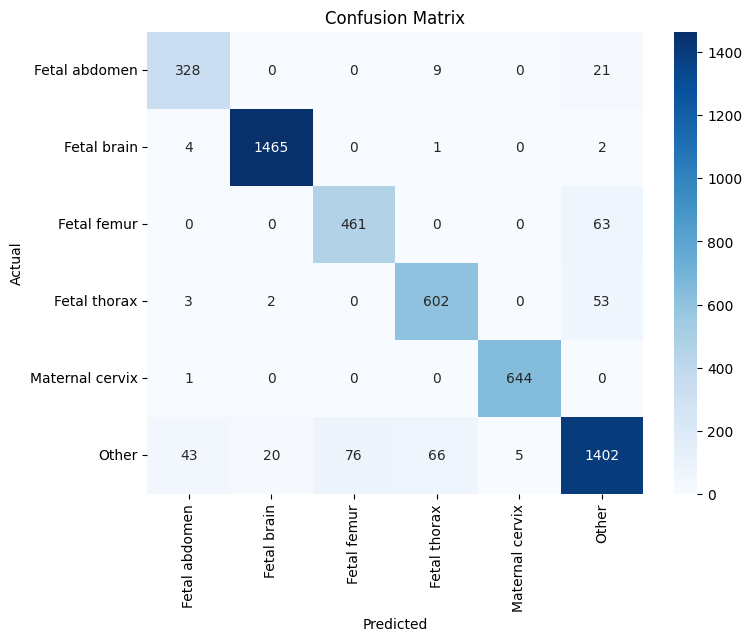

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
classes = ['Fetal abdomen', 'Fetal brain', 'Fetal femur',
           'Fetal thorax', 'Maternal cervix', 'Other']
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
print("=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=classes))
cm = confusion_matrix(all_labels, all_preds)
print("\n=== Confusion Matrix ===")
print(cm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/resnet50_fetal_planes.pth")

In [ ]:
from google.colab import files
files.download("resnet50_fetal_planes.pth")

In [ ]:
import pandas as pd

df = pd.read_csv("/content/fetal_planes/FETAL_PLANES_DB_data.csv")
df.head()

,Image_name;Patient_num;Plane;Brain_plane;Operator;US_Machine;Train
0,Patient00001_Plane1_1_of_15;1;Other;Not A Brai...
1,Patient00001_Plane1_2_of_15;1;Other;Not A Brai...
2,Patient00001_Plane1_3_of_15;1;Other;Not A Brai...
3,Patient00001_Plane1_4_of_15;1;Other;Not A Brai...
4,Patient00001_Plane1_5_of_15;1;Other;Not A Brai...


In [ ]:
df = pd.read_csv("/content/fetal_planes/FETAL_PLANES_DB_data.csv", sep=';')

In [ ]:
print(df.columns)

Index(['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator',
       'US_Machine', 'Train '],
      dtype='object')


In [ ]:
print(df['Plane'].unique())

['Other' 'Maternal cervix' 'Fetal abdomen' 'Fetal brain' 'Fetal femur'
 'Fetal thorax']


In [ ]:
femur_df = df[df['Plane'].str.contains('femur', case=False)]
print(len(femur_df))

1040


In [ ]:
import pandas as pd
import cv2
import numpy as np
df = pd.read_csv("/content/fetal_planes/FETAL_PLANES_DB_data.csv", sep=';')
femur_df = df[df['Plane'].str.contains('femur', case=False)].reset_index(drop=True)
results = []
for i in range(50):
    img_name = femur_df.iloc[i]['Image_name']
    img_path = f"/content/fetal_planes/Images/{img_name}.png"
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(2.0, (8,8))
    gray = clahe.apply(gray)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    edges = cv2.Canny(blur, 50, 150)
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=80,
        minLineLength=80,
        maxLineGap=10
    )
    if lines is None:
        continue
    best_line = None
    max_len = 0
    for line in lines:
        x1, y1, x2, y2 = line[0]
        dx = x2 - x1
        dy = y2 - y1
        length = np.hypot(dx, dy)
        angle = abs(np.degrees(np.arctan2(dy, dx)))
        if angle < 15 or angle > 165:
            continue
        if length > max_len:
            max_len = length
            best_line = (x1, y1, x2, y2)
    if best_line is None:
        continue

    if max_len < 100 or max_len > 320:
        continue
    results.append(max_len)

    print(f"[{i}]  Femur length (pixels): {max_len:.2f}")
results_df = pd.DataFrame(results, columns=['length_px'])

print("\n Summary:")
print(results_df.describe())
if len(results_df) > 0:
    median_px = results_df['length_px'].median()
    pixel_to_mm = 45 / median_px
    results_df['length_mm'] = results_df['length_px'] * pixel_to_mm
    print("\n With Approx Conversion:")
    print(results_df.describe())

[0]  Femur length (pixels): 217.00
[1]  Femur length (pixels): 312.54
[3]  Femur length (pixels): 245.20
[4]  Femur length (pixels): 189.00
[5]  Femur length (pixels): 195.00
[6]  Femur length (pixels): 194.00
[7]  Femur length (pixels): 268.78
[10]  Femur length (pixels): 188.00
[13]  Femur length (pixels): 190.00
[14]  Femur length (pixels): 195.00
[15]  Femur length (pixels): 195.00
[16]  Femur length (pixels): 199.82
[18]  Femur length (pixels): 310.46
[19]  Femur length (pixels): 295.70
[21]  Femur length (pixels): 195.00
[23]  Femur length (pixels): 188.00
[24]  Femur length (pixels): 188.00
[25]  Femur length (pixels): 195.36
[26]  Femur length (pixels): 195.00
[27]  Femur length (pixels): 188.00
[28]  Femur length (pixels): 188.00
[29]  Femur length (pixels): 185.00
[34]  Femur length (pixels): 193.00
[35]  Femur length (pixels): 186.00
[37]  Femur length (pixels): 241.50
[38]  Femur length (pixels): 212.13
[39]  Femur length (pixels): 213.22
[40]  Femur length (pixels): 181.00

In [ ]:

import cv2
import numpy as np

def detect_femur_length(image):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(2.0, (8,8))
    gray = clahe.apply(gray)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    edges = cv2.Canny(blur, 50, 150)

    lines = cv2.HoughLinesP(
        edges,
        1,
        np.pi/180,
        threshold=80,
        minLineLength=80,
        maxLineGap=10
    )

    if lines is None:
        return None

    max_len = 0

    for line in lines:
        x1, y1, x2, y2 = line[0]

        dx = x2 - x1
        dy = y2 - y1

        length = np.hypot(dx, dy)
        angle = abs(np.degrees(np.arctan2(dy, dx)))

        if angle < 15 or angle > 165:
            continue

        if length > max_len:
            max_len = length

    if max_len < 100 or max_len > 320:
        return None

    return max_len

In [ ]:
img_name = femur_df.iloc[0]['Image_name']
img_path = f"/content/fetal_planes/Images/{img_name}.png"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

length = detect_femur_length(img)

print("Final Femur Length (px):", length)

Final Femur Length (px): 217.0


In [56]:

with open("/content/femur.py", "w") as f:
    f.write("""import cv2
import numpy as np

def detect_femur_length(image):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(2.0, (8,8))
    gray = clahe.apply(gray)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    edges = cv2.Canny(blur, 50, 150)

    lines = cv2.HoughLinesP(
        edges,
        1,
        np.pi/180,
        threshold=80,
        minLineLength=80,
        maxLineGap=10
    )

    if lines is None:
        return None

    max_len = 0

    for line in lines:
        x1, y1, x2, y2 = line[0]

        dx = x2 - x1
        dy = y2 - y1

        length = np.hypot(dx, dy)
        angle = abs(np.degrees(np.arctan2(dy, dx)))

        if angle < 15 or angle > 165:
            continue

        if length > max_len:
            max_len = length

    if max_len < 100 or max_len > 320:
        return None

    return max_len
""")